# Poster Bike Weather

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [152]:
df = pd.read_pickle("bike_weather_data.pickle")
df.head()


,temperature,humidity,precipitation,bike_usage
0,12.8,55,5.8,True
1,26.1,78,9.6,False
2,19.0,84,1.1,False
3,30.5,43,5.3,False
4,21.3,47,3.8,True


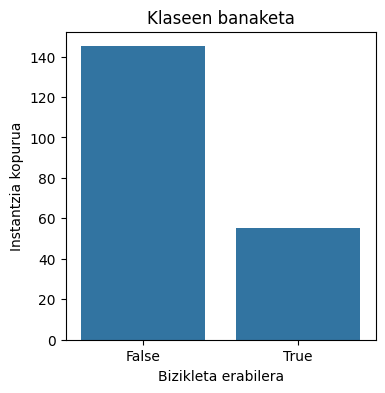

In [153]:
colors = {True: 'springgreen', False: 'red'}

bike_kont = df['bike_usage'].value_counts()

plt.figure(figsize=(4, 4))
sns.barplot(x=bike_kont.index, y=bike_kont.values)
plt.title('Klaseen banaketa')
plt.xlabel('Bizikleta erabilera')
plt.ylabel('Instantzia kopurua')
plt.savefig('grafikoak/klase_banaketa.svg', 
            format='svg', 
            dpi=300,
            bbox_inches='tight')
plt.show()

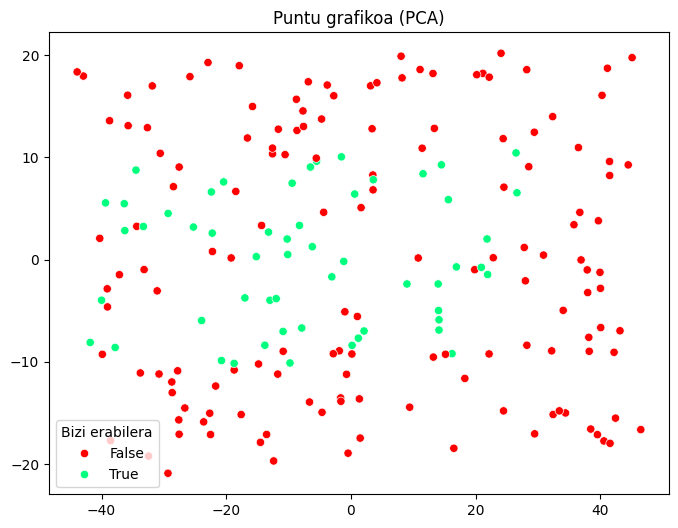

In [154]:
# Klasea banatu
X = df[['temperature', 'humidity', 'precipitation']]
y = df['bike_usage']

# PCA 2D-ra murrizteko
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# DataFrame plot-entzat
df_pca = pd.DataFrame(X_pca, columns=['X', 'Y'])
df_pca['Bizi erabilera'] = y

# Puntu grafikoa
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='X', y='Y', hue='Bizi erabilera', palette=colors)
plt.title('Puntu grafikoa (PCA)')
plt.xlabel('')
plt.ylabel('')
plt.savefig('grafikoak/puntu_grafikoa_PCA.svg', 
            format='svg', 
            dpi=300,
            bbox_inches='tight')
plt.show()

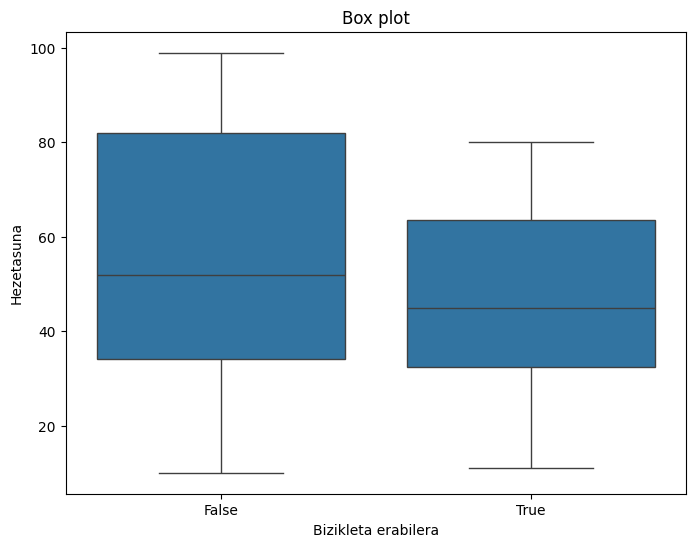

In [155]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='bike_usage', y='humidity')
plt.title('Box plot')
plt.xlabel('Bizikleta erabilera')
plt.ylabel('Hezetasuna')
plt.savefig('grafikoak/box_plot.svg', 
            format='svg', 
            dpi=300,
            bbox_inches='tight')
plt.show()

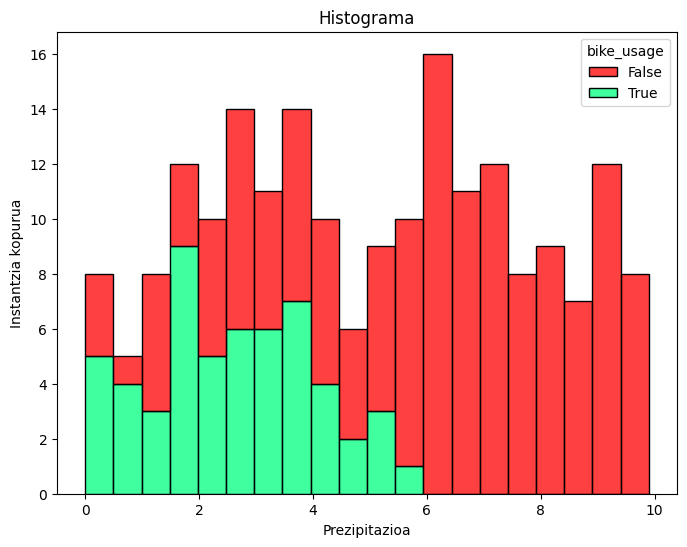

In [156]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='precipitation', hue='bike_usage', multiple='stack', bins=20, palette=colors)
plt.title('Histograma')
plt.xlabel('Prezipitazioa')
plt.ylabel('Instantzia kopurua')
plt.savefig('grafikoak/histograma.svg', 
            format='svg', 
            dpi=300,
            bbox_inches='tight')
plt.show()

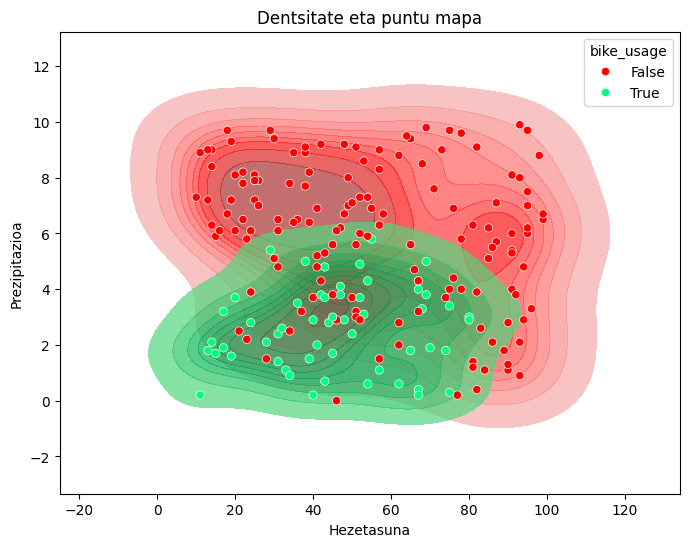

In [157]:
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='humidity', y='precipitation', hue='bike_usage', fill=True, alpha=0.7, palette=colors)
sns.scatterplot(data=df, x='humidity', y='precipitation', hue='bike_usage', palette=colors)
plt.title('Dentsitate eta puntu mapa')
plt.xlabel('Hezetasuna')
plt.ylabel('Prezipitazioa')
plt.savefig('grafikoak/dentsitate_puntu_mapa.svg', 
            format='svg', 
            dpi=300,
            bbox_inches='tight')
plt.show()